<a href="https://colab.research.google.com/github/semmatoninn/CHE1148_MOFs_AtomicWizards/blob/main/Final_GNN_FullStructure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1) INSTALL
%%capture
# Check runtime first: Runtime -> Change runtime type -> GPU
!nvidia-smi

import os
import sys
import subprocess

# Install PyG wheels matched to current Colab torch/cuda
import torch
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

TORCH = torch.__version__.split("+")[0]
CUDA = "cpu" if torch.version.cuda is None else "cu" + torch.version.cuda.replace(".", "")

# Official PyG wheel index pattern
!pip -qq install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

!pip -qq install torch_geometric
!pip -qq install scipy pandas scikit-learn tqdm

print("Install done.")

In [ ]:
# 2) MOUNT DRIVE + IMPORTS

from google.colab import drive
drive.mount('/content/drive')

import math
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool, radius_graph
from torch_geometric.utils import remove_self_loops

from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mounted at /content/drive
Device: cuda


In [ ]:
# 3) PATHS + CONFIG

BASE_DIR = Path("/content/drive/MyDrive/MOF_Conf/processed_pyg")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"
TEST_DIR  = BASE_DIR / "test"

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

# Training / graph settings
SEED = 42
BATCH_SIZE = 8
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 100
PATIENCE = 15

# Graph construction
CUTOFF = 5.0
MAX_NEIGHBORS = 32

# Model size
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 4
DROPOUT = 0.1

# RBF edge features
NUM_RBF = 16
RBF_GAMMA = 10.0

# Hybrid loss
MSE_WEIGHT = 1.0
RANK_WEIGHT = 0.25

# Ensemble
ENSEMBLE_SIZE = 3
ENSEMBLE_SEED_GAP = 17

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

/content/drive/MyDrive/MOF_Conf/processed_pyg/train
/content/drive/MyDrive/MOF_Conf/processed_pyg/val
/content/drive/MyDrive/MOF_Conf/processed_pyg/test


In [ ]:
# 4) LOAD CHUNKED DATA

def sorted_pt_files(folder: Path):
    return sorted(folder.glob("*.pt"))

train_files = sorted_pt_files(TRAIN_DIR)
val_files   = sorted_pt_files(VAL_DIR)
test_files  = sorted_pt_files(TEST_DIR)

print("Train files:", [f.name for f in train_files])
print("Val files:", [f.name for f in val_files])
print("Test files:", [f.name for f in test_files])

def load_chunk_list(pt_files):
    data_list = []
    for f in pt_files:
        print(f"Loading {f.name} ...")
        chunk = torch.load(f, map_location="cpu", weights_only=False)
        if isinstance(chunk, list):
            data_list.extend(chunk)
        else:
            raise TypeError(f"Unexpected object in {f}: {type(chunk)}")
    return data_list

train_data = load_chunk_list(train_files)
val_data   = load_chunk_list(val_files)
test_data  = load_chunk_list(test_files)

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
print(f"Test samples:  {len(test_data)}")

sample = train_data[0]
print(sample)
print("Keys:", sample.keys())
print("z shape:", sample.z.shape)
print("pos shape:", sample.pos.shape)
print("y:", sample.y)
print("mof_name:", sample.mof_name)
print("config_name:", sample.config_name)

Train files: ['train_part_000.pt', 'train_part_001.pt', 'train_part_002.pt', 'train_part_003.pt']
Val files: ['val_part_000.pt']
Test files: ['test_part_000.pt']
Loading train_part_000.pt ...
Loading train_part_001.pt ...
Loading train_part_002.pt ...
Loading train_part_003.pt ...
Loading val_part_000.pt ...
Loading test_part_000.pt ...
Train samples: 1860
Val samples:   427
Test samples:  444
Data(y=[1], pos=[277, 3], z=[277], cell=[3, 3], pbc=[3], mof_name='ADOBEB_charged', config_name='ADOBEB_charged_w_CO2_1', num_atoms=277, split='train')
Keys: ['pos', 'pbc', 'mof_name', 'z', 'split', 'num_atoms', 'cell', 'y', 'config_name']
z shape: torch.Size([277])
pos shape: torch.Size([277, 3])
y: tensor([-0.1344])
mof_name: ADOBEB_charged
config_name: ADOBEB_charged_w_CO2_1


In [ ]:
# 5) PRECOMPUTE EDGE_INDEX

def ensure_tensor_y(data):
    # make sure y is float tensor of shape [1]
    if not torch.is_tensor(data.y):
        data.y = torch.tensor([float(data.y)], dtype=torch.float)
    else:
        data.y = data.y.view(-1).float()
        if data.y.numel() == 1:
            pass
        else:
            data.y = data.y[:1]
    return data

def add_radius_edges(data, cutoff=CUTOFF, max_neighbors=MAX_NEIGHBORS):
    data = ensure_tensor_y(data)

    if hasattr(data, "edge_index") and data.edge_index is not None:
        return data

    pos = data.pos.float()
    edge_index = radius_graph(
        x=pos,
        r=cutoff,
        loop=False,
        max_num_neighbors=max_neighbors
    )
    edge_index, _ = remove_self_loops(edge_index)
    data.edge_index = edge_index
    return data

def preprocess_dataset(data_list, cutoff=CUTOFF, max_neighbors=MAX_NEIGHBORS):
    processed = []
    for data in tqdm(data_list):
        d = add_radius_edges(data, cutoff=cutoff, max_neighbors=max_neighbors)
        processed.append(d)
    return processed

train_data = preprocess_dataset(train_data)
val_data   = preprocess_dataset(val_data)
test_data  = preprocess_dataset(test_data)

# inspect one sample
s = train_data[0]
print("edge_index shape:", s.edge_index.shape)
print("num_nodes:", s.num_nodes)
print("num_edges:", s.edge_index.shape[1])

  0%|          | 0/1860 [00:00<?, ?it/s]

  0%|          | 0/427 [00:00<?, ?it/s]

  0%|          | 0/444 [00:00<?, ?it/s]

edge_index shape: torch.Size([2, 6345])
num_nodes: 277
num_edges: 6345


In [ ]:
# 6) DATALOADERS
NUM_WORKERS = 0
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

batch = next(iter(train_loader))
print(batch)
print("Batch num graphs:", batch.num_graphs)
print("Batch x nodes:", batch.z.shape)
print("Batch pos:", batch.pos.shape)
print("Batch y:", batch.y.shape)

DataBatch(y=[8], pos=[1544, 3], z=[1544], cell=[24, 3], pbc=[24], mof_name=[8], config_name=[8], num_atoms=[8], split=[8], edge_index=[2, 33040], batch=[1544], ptr=[9])
Batch num graphs: 8
Batch x nodes: torch.Size([1544])
Batch pos: torch.Size([1544, 3])
Batch y: torch.Size([8])


In [ ]:
# 7) MODEL - EGNN WITH RBF EDGE FEATURES

# 7) MODEL - EGNN WITH RBF EDGE FEATURES

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_mean_pool

def radial_basis(dist, num_rbf=16, cutoff=5.0, gamma=10.0):
    """
    dist: [num_edges, 1]
    returns: [num_edges, num_rbf]
    """
    centers = torch.linspace(0.0, cutoff, num_rbf, device=dist.device).view(1, -1)
    return torch.exp(-gamma * (dist - centers) ** 2)

class StableEGNNLayer(MessagePassing):
    def __init__(self, hidden_dim, num_rbf=16, cutoff=5.0, rbf_gamma=10.0, dropout=0.0):
        super().__init__(aggr='add')
        self.hidden_dim = hidden_dim
        self.num_rbf = num_rbf
        self.cutoff = cutoff
        self.rbf_gamma = rbf_gamma

        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + num_rbf, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, pos, edge_index):
        row, col = edge_index

        rel = pos[row] - pos[col]
        dist = torch.norm(rel, dim=-1, keepdim=True)
        dist = torch.clamp(dist, min=0.0, max=self.cutoff)

        rbf = radial_basis(
            dist,
            num_rbf=self.num_rbf,
            cutoff=self.cutoff,
            gamma=self.rbf_gamma
        )

        m_ij = self.edge_mlp(torch.cat([h[row], h[col], rbf], dim=-1))
        m_ij = self.dropout(m_ij)

        agg = torch.zeros_like(h)
        agg.index_add_(0, row, m_ij)

        h_update = self.node_mlp(torch.cat([h, agg], dim=-1))
        h = self.norm(h + h_update)
        return h


class EnergyEGNN(nn.Module):
    def __init__(
        self,
        num_atom_types=120,
        embed_dim=128,
        hidden_dim=128,
        num_layers=4,
        num_rbf=16,
        cutoff=5.0,
        rbf_gamma=10.0,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(num_atom_types, embed_dim)
        self.input_proj = nn.Linear(embed_dim, hidden_dim)

        self.layers = nn.ModuleList([
            StableEGNNLayer(
                hidden_dim=hidden_dim,
                num_rbf=num_rbf,
                cutoff=cutoff,
                rbf_gamma=rbf_gamma,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        z = data.z.long()
        pos = data.pos.float()
        edge_index = data.edge_index
        batch = data.batch

        h = self.embedding(z)
        h = self.input_proj(h)

        for layer in self.layers:
            h = layer(h, pos, edge_index)

        g = global_mean_pool(h, batch)
        out = self.readout(g).view(-1)
        return out

In [ ]:
# 8) INIT TRAINING OBJECTS + HYBRID LOSS

def build_model():
    return EnergyEGNN(
        num_atom_types=120,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_rbf=NUM_RBF,
        cutoff=CUTOFF,
        rbf_gamma=RBF_GAMMA,
        dropout=DROPOUT
    )

def pairwise_ranking_loss(y_pred, y_true):
    """
    Pairwise ranking loss inside a batch.
    Encourages correct ordering for MOF screening.
    """
    y_pred = y_pred.view(-1)
    y_true = y_true.view(-1)

    diff_true = y_true.unsqueeze(1) - y_true.unsqueeze(0)
    diff_pred = y_pred.unsqueeze(1) - y_pred.unsqueeze(0)

    mask = torch.abs(diff_true) > 1e-12
    if mask.sum() == 0:
        return torch.tensor(0.0, device=y_pred.device)

    sign_true = torch.sign(diff_true[mask])
    rank_loss = F.softplus(-sign_true * diff_pred[mask]).mean()
    return rank_loss

def hybrid_loss(y_pred, y_true, mse_weight=1.0, rank_weight=0.25):
    mse = F.mse_loss(y_pred, y_true)
    rank = pairwise_ranking_loss(y_pred, y_true)
    total = mse_weight * mse + rank_weight * rank
    return total, mse.detach(), rank.detach()

# smoke test model
model = build_model().to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {num_params:,}")

Trainable params: 461,185


In [ ]:

# 9) METRICS + AGGREGATION

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def safe_rank_corr(y_true, y_pred):
    sp = spearmanr(y_true, y_pred).correlation
    kt = kendalltau(y_true, y_pred).correlation
    return sp, kt

def aggregate_by_mof(records, agg="mean"):
    """
    records: list of dicts with keys:
      mof_name, y_true, y_pred
    returns per-MOF arrays
    """
    by_mof = defaultdict(lambda: {"y_true": [], "y_pred": []})

    for r in records:
        by_mof[r["mof_name"]]["y_true"].append(float(r["y_true"]))
        by_mof[r["mof_name"]]["y_pred"].append(float(r["y_pred"]))

    mof_names = []
    y_true_mof = []
    y_pred_mof = []

    for mof, vals in by_mof.items():
        yt = np.array(vals["y_true"], dtype=float)
        yp = np.array(vals["y_pred"], dtype=float)

        if agg == "mean":
            yt_agg = yt.mean()
            yp_agg = yp.mean()
        elif agg == "min":
            yt_agg = yt.min()
            yp_agg = yp.min()
        else:
            raise ValueError("agg must be 'mean' or 'min'")

        mof_names.append(mof)
        y_true_mof.append(yt_agg)
        y_pred_mof.append(yp_agg)

    return mof_names, np.array(y_true_mof), np.array(y_pred_mof)

def compute_mof_metrics(records, agg="mean"):
    mof_names, y_true_mof, y_pred_mof = aggregate_by_mof(records, agg=agg)

    metrics = {
        "n_mofs": len(mof_names),
        "RMSE": rmse(y_true_mof, y_pred_mof),
        "MAE": mean_absolute_error(y_true_mof, y_pred_mof),
    }

    sp, kt = safe_rank_corr(y_true_mof, y_pred_mof)
    metrics["Spearman"] = sp
    metrics["Kendall"] = kt

    return metrics, mof_names, y_true_mof, y_pred_mof

In [ ]:
# 10) TRAIN + EVAL HELPERS

def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    mse_weight=1.0,
    rank_weight=0.25
):
    model.train()
    running_loss = 0.0
    running_mse = 0.0
    running_rank = 0.0
    n_graphs = 0

    for batch in tqdm(loader, leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(batch)
        target = batch.y.view(-1).float()

        loss, mse_term, rank_term = hybrid_loss(
            pred,
            target,
            mse_weight=mse_weight,
            rank_weight=rank_weight
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = batch.num_graphs
        running_loss += loss.item() * bs
        running_mse += mse_term.item() * bs
        running_rank += rank_term.item() * bs
        n_graphs += bs

    denom = max(n_graphs, 1)
    return {
        "loss": running_loss / denom,
        "mse": running_mse / denom,
        "rank": running_rank / denom
    }


@torch.no_grad()
def predict_records(model, loader, device, member_id=None):
    model.eval()
    records = []

    for batch in tqdm(loader, leave=False):
        batch = batch.to(device)
        pred = model(batch).detach().cpu().numpy()
        true = batch.y.view(-1).detach().cpu().numpy()

        mof_names = batch.mof_name
        config_names = batch.config_name if hasattr(batch, "config_name") else [None] * len(pred)

        for i in range(len(pred)):
            row = {
                "mof_name": mof_names[i],
                "config_name": config_names[i],
                "y_true": float(true[i]),
                "y_pred": float(pred[i]),
            }
            if member_id is not None:
                row["member_id"] = member_id
            records.append(row)

    return records


def evaluate_loader(model, loader, device):
    records = predict_records(model, loader, device)

    mean_metrics, mean_mofs, mean_true, mean_pred = compute_mof_metrics(records, agg="mean")
    min_metrics,  min_mofs,  min_true,  min_pred  = compute_mof_metrics(records, agg="min")

    return {
        "records": records,
        "mean_metrics": mean_metrics,
        "min_metrics": min_metrics,
        "mean_arrays": (mean_mofs, mean_true, mean_pred),
        "min_arrays": (min_mofs, min_true, min_pred),
    }


@torch.no_grad()
def predict_records_ensemble(models, loader, device):
    """
    Returns config-level mean and std across ensemble members.
    Assumes deterministic DataLoader ordering.
    """
    all_member_records = []
    per_member_preds = []

    for member_id, model in enumerate(models):
        member_records = predict_records(model, loader, device, member_id=member_id)
        all_member_records.extend(member_records)
        per_member_preds.append([r["y_pred"] for r in member_records])

    pred_matrix = np.array(per_member_preds)  # [n_members, n_samples]
    pred_mean = pred_matrix.mean(axis=0)
    pred_std  = pred_matrix.std(axis=0)

    base_records = predict_records(models[0], loader, device)

    ensemble_records = []
    for i, r in enumerate(base_records):
        ensemble_records.append({
            "mof_name": r["mof_name"],
            "config_name": r["config_name"],
            "y_true": r["y_true"],
            "y_pred": float(pred_mean[i]),
            "y_pred_std": float(pred_std[i]),
        })

    return ensemble_records, all_member_records


def evaluate_loader_ensemble(models, loader, device):
    records, all_member_records = predict_records_ensemble(models, loader, device)

    mean_metrics, mean_mofs, mean_true, mean_pred = compute_mof_metrics(records, agg="mean")
    min_metrics,  min_mofs,  min_true,  min_pred  = compute_mof_metrics(records, agg="min")

    return {
        "records": records,
        "all_member_records": all_member_records,
        "mean_metrics": mean_metrics,
        "min_metrics": min_metrics,
        "mean_arrays": (mean_mofs, mean_true, mean_pred),
        "min_arrays": (min_mofs, min_true, min_pred),
    }

In [ ]:
# 11) EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=15, mode="min"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, score, model):
        improved = False

        if self.best_score is None:
            improved = True
        elif self.mode == "min" and score < self.best_score:
            improved = True
        elif self.mode == "max" and score > self.best_score:
            improved = True

        if improved:
            self.best_score = score
            self.counter = 0
            self.best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [ ]:
# 12) ENSEMBLE TRAINING LOOP

def train_single_member(member_id, seed):
    print(f"\n{'='*70}")
    print(f"Training ensemble member {member_id + 1}/{ENSEMBLE_SIZE} | seed={seed}")
    print(f"{'='*70}")

    seed_everything(seed)

    model = build_model().to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.7,
        patience=5
    )

    early_stopper = EarlyStopping(patience=PATIENCE, mode="max")
    member_history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_stats = train_one_epoch(
            model,
            train_loader,
            optimizer,
            device,
            mse_weight=MSE_WEIGHT,
            rank_weight=RANK_WEIGHT
        )

        val_out = evaluate_loader(model, val_loader, device)
        val_mean = val_out["mean_metrics"]
        val_min  = val_out["min_metrics"]

        # ranking-focused monitoring for screening
        monitor = val_min["Spearman"]
        scheduler.step(monitor)
        early_stopper.step(monitor, model)

        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "member_id": member_id,
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_mse_term": train_stats["mse"],
            "train_rank_term": train_stats["rank"],
            "val_mean_RMSE": val_mean["RMSE"],
            "val_mean_MAE": val_mean["MAE"],
            "val_mean_Spearman": val_mean["Spearman"],
            "val_mean_Kendall": val_mean["Kendall"],
            "val_min_RMSE": val_min["RMSE"],
            "val_min_MAE": val_min["MAE"],
            "val_min_Spearman": val_min["Spearman"],
            "val_min_Kendall": val_min["Kendall"],
            "lr": lr_now,
        }
        member_history.append(row)

        print(
            f"Member {member_id + 1} | Epoch {epoch:03d} | "
            f"train={train_stats['loss']:.5f} "
            f"(mse={train_stats['mse']:.5f}, rank={train_stats['rank']:.5f}) | "
            f"val_min_S={val_min['Spearman']:.4f} | "
            f"val_min_K={val_min['Kendall']:.4f} | "
            f"val_min_RMSE={val_min['RMSE']:.5f} | "
            f"lr={lr_now:.2e}"
        )

        if early_stopper.should_stop:
            print(f"Early stopping triggered for member {member_id + 1} at epoch {epoch}.")
            break

    if early_stopper.best_state is not None:
        model.load_state_dict(early_stopper.best_state)
        print(f"Loaded best checkpoint for member {member_id + 1}.")

    return model, member_history


ensemble_models = []
history = []

for member_id in range(ENSEMBLE_SIZE):
    member_seed = SEED + member_id * ENSEMBLE_SEED_GAP
    trained_model, member_history = train_single_member(member_id, member_seed)
    ensemble_models.append(trained_model)
    history.extend(member_history)

print(f"\nFinished training {len(ensemble_models)} ensemble members.")


Training ensemble member 1/3 | seed=42


  0%|          | 0/233 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

Member 1 | Epoch 001 | train=0.43416 (mse=0.26170, rank=0.68982) | val_min_S=0.3966 | val_min_K=0.2611 | val_min_RMSE=1.15875 | lr=1.00e-04


  0%|          | 0/233 [00:00<?, ?it/s]

...

  0%|          | 0/54 [00:00<?, ?it/s]

Member 3 | Epoch 054 | train=0.29834 (mse=0.14784, rank=0.60200) | val_min_S=0.5936 | val_min_K=0.4384 | val_min_RMSE=0.99083 | lr=2.40e-05


  0%|          | 0/233 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

Member 3 | Epoch 055 | train=0.30404 (mse=0.15216, rank=0.60754) | val_min_S=0.5700 | val_min_K=0.4089 | val_min_RMSE=0.98584 | lr=2.40e-05
Early stopping triggered for member 3 at epoch 55.
Loaded best checkpoint for member 3.

Finished training 3 ensemble members.


In [ ]:
# 13) FINAL VALIDATION + TEST (ENSEMBLE)

val_final = evaluate_loader_ensemble(ensemble_models, val_loader, device)
test_final = evaluate_loader_ensemble(ensemble_models, test_loader, device)

print("\n=== VALIDATION (MOF-level, mean agg, ensemble mean) ===")
for k, v in val_final["mean_metrics"].items():
    print(f"{k}: {v}")

print("\n=== VALIDATION (MOF-level, min agg, ensemble mean) ===")
for k, v in val_final["min_metrics"].items():
    print(f"{k}: {v}")

print("\n=== TEST (MOF-level, mean agg, ensemble mean) ===")
for k, v in test_final["mean_metrics"].items():
    print(f"{k}: {v}")

print("\n=== TEST (MOF-level, min agg, ensemble mean) ===")
for k, v in test_final["min_metrics"].items():
    print(f"{k}: {v}")

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]


=== VALIDATION (MOF-level, mean agg, ensemble mean) ===
n_mofs: 29
RMSE: 0.24060541531919719
MAE: 0.17840763024322512
Spearman: 0.5965517241379309
Kendall: 0.4137931034482758

=== VALIDATION (MOF-level, min agg, ensemble mean) ===
n_mofs: 29
RMSE: 1.0251895233119526
MAE: 0.702116077573135
Spearman: 0.6729064039408865
Kendall: 0.4729064039408866

=== TEST (MOF-level, mean agg, ensemble mean) ===
n_mofs: 30
RMSE: 0.29086040376005307
MAE: 0.2212937423098716
Spearman: 0.4958843159065628
Kendall: 0.36091954022988504

=== TEST (MOF-level, min agg, ensemble mean) ===
n_mofs: 30
RMSE: 0.8129315935637893
MAE: 0.6287235789000989
Spearman: 0.5394883203559511
Kendall: 0.40689655172413797


In [ ]:
# 14) SAVE PREDICTIONS + MOF RANKINGS + UNCERTAINTY
from pathlib import Path
OUT_DIR = Path("/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save epoch history
hist_df = pd.DataFrame(history)
hist_df.to_csv(OUT_DIR / "training_history_ensemble.csv", index=False)

# Save config-level predictions (ensemble mean/std)
test_records_df = pd.DataFrame(test_final["records"])
val_records_df  = pd.DataFrame(val_final["records"])

test_records_df.to_csv(OUT_DIR / "test_config_predictions_ensemble.csv", index=False)
val_records_df.to_csv(OUT_DIR / "val_config_predictions_ensemble.csv", index=False)

# Save per-member predictions too
test_member_df = pd.DataFrame(test_final["all_member_records"])
val_member_df  = pd.DataFrame(val_final["all_member_records"])

test_member_df.to_csv(OUT_DIR / "test_config_predictions_all_members.csv", index=False)
val_member_df.to_csv(OUT_DIR / "val_config_predictions_all_members.csv", index=False)

def build_mof_df_with_uncertainty(eval_out, agg="mean"):
    records_df = pd.DataFrame(eval_out["records"])

    if agg == "mean":
        grp = records_df.groupby("mof_name", as_index=False).agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean"),
            y_pred_std_mean=("y_pred_std", "mean"),
            y_pred_std_max=("y_pred_std", "max"),
            n_configs=("y_pred", "size")
        )
    elif agg == "min":
        idx = records_df.groupby("mof_name")["y_pred"].idxmin()
        grp = records_df.loc[idx, ["mof_name", "y_true", "y_pred", "y_pred_std"]].copy()
        grp = grp.rename(columns={"y_pred_std": "y_pred_std_at_best_config"})
        grp["n_configs"] = records_df.groupby("mof_name").size().reindex(grp["mof_name"]).values
    else:
        raise ValueError("agg must be 'mean' or 'min'")

    grp = grp.sort_values("y_pred", ascending=True).reset_index(drop=True)
    grp["pred_rank"] = np.arange(1, len(grp) + 1)
    return grp

test_mof_mean_df = build_mof_df_with_uncertainty(test_final, agg="mean")
test_mof_min_df  = build_mof_df_with_uncertainty(test_final, agg="min")
val_mof_mean_df  = build_mof_df_with_uncertainty(val_final, agg="mean")
val_mof_min_df   = build_mof_df_with_uncertainty(val_final, agg="min")

test_mof_mean_df.to_csv(OUT_DIR / "test_mof_rankings_mean_ensemble.csv", index=False)
test_mof_min_df.to_csv(OUT_DIR / "test_mof_rankings_min_ensemble.csv", index=False)
val_mof_mean_df.to_csv(OUT_DIR / "val_mof_rankings_mean_ensemble.csv", index=False)
val_mof_min_df.to_csv(OUT_DIR / "val_mof_rankings_min_ensemble.csv", index=False)

print("Saved outputs to:", OUT_DIR)
print("\nTop 10 test MOFs by ensemble min prediction:")
print(test_mof_min_df.head(10))

Saved outputs to: /content/drive/MyDrive/MOF_Conf/egnn_results_ensemble

Top 10 test MOFs by ensemble min prediction:
                  mof_name    y_true    y_pred  y_pred_std_at_best_config  \
0                   DAGDIZ -1.441011 -1.191846                   0.231705   
1                   VUHJAK -0.903523 -0.837590                   0.057601   
2            XEHSIN_0.02_0 -1.360008 -0.778407                   0.064255   
3         jz4002345_si_002 -0.786088 -0.773051                   0.037782   
4            ATOWIQ_0.16_1 -0.809744 -0.764376                   0.060691   
5  ja506357n_si_002_0.12_0 -1.241694 -0.735356                   0.011665   
6            ATOWIQ_0.16_0 -1.177057 -0.694788                   0.041635   
7                   HAXMUP -0.232833 -0.662858                   0.119982   
8                   RILVOZ -0.269434 -0.630673                   0.047656   
9                   JOFKIA -1.045569 -0.611647                   0.045710   

   n_configs  pred_rank  
0       

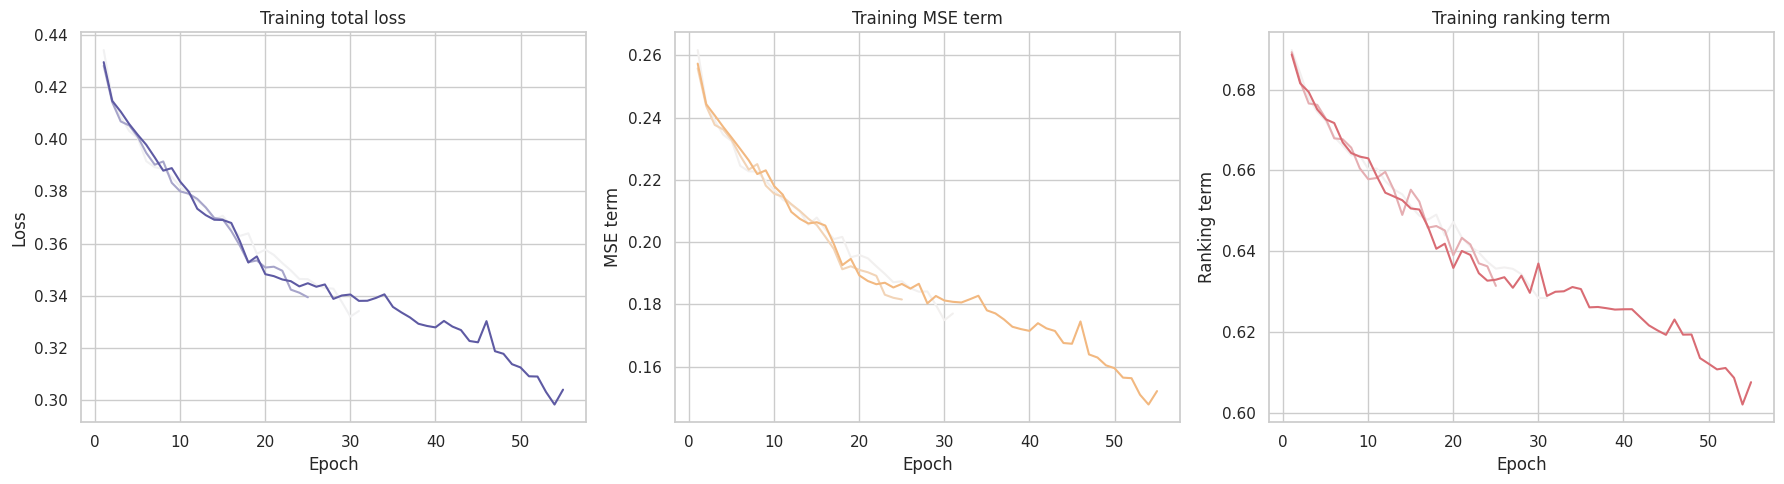

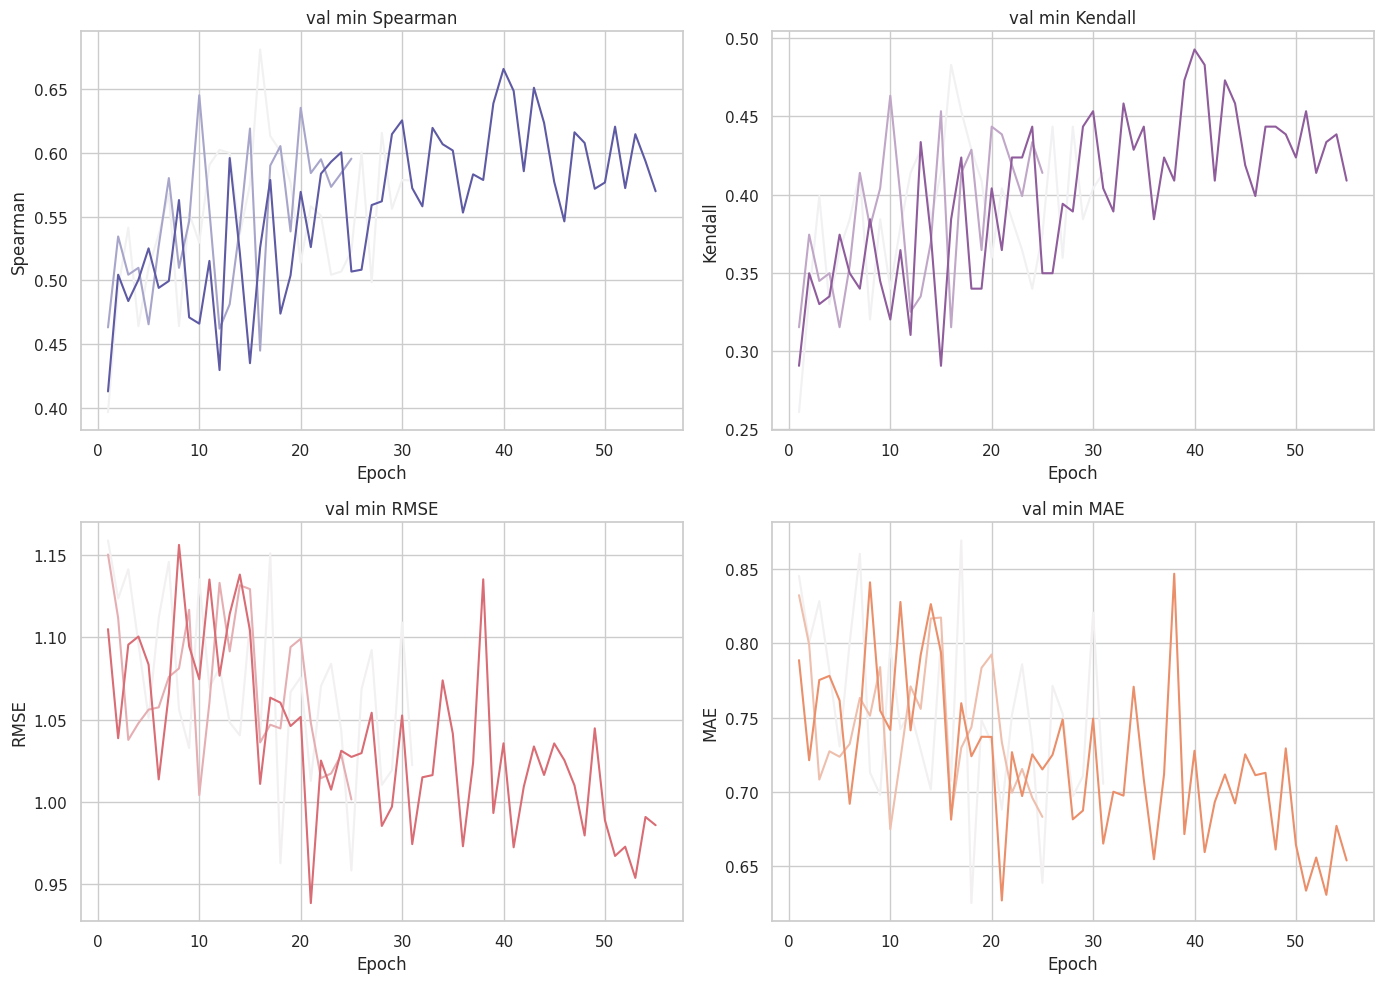

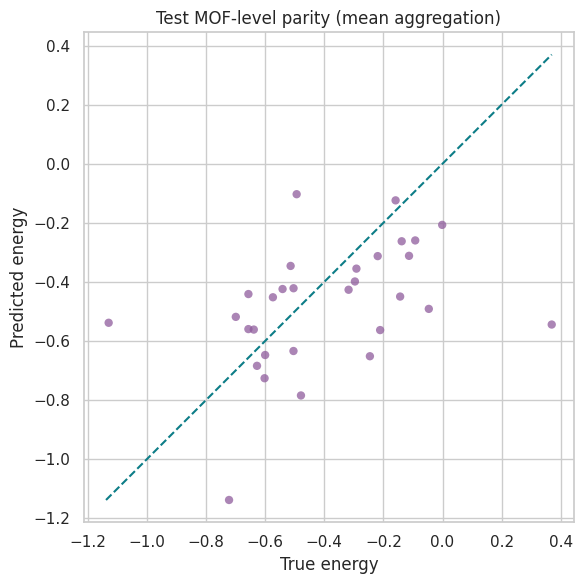

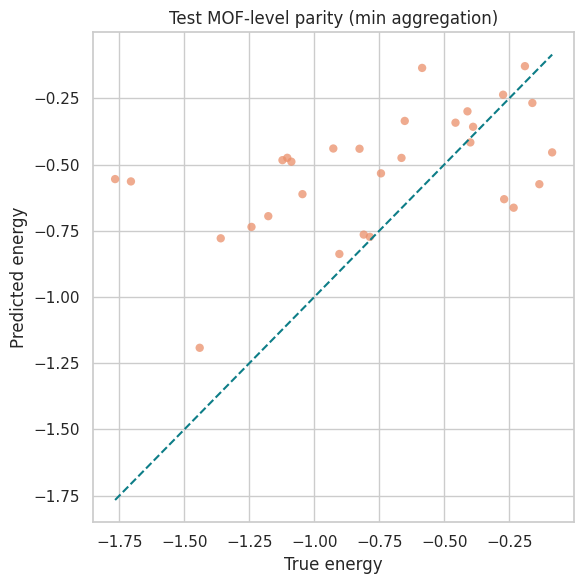

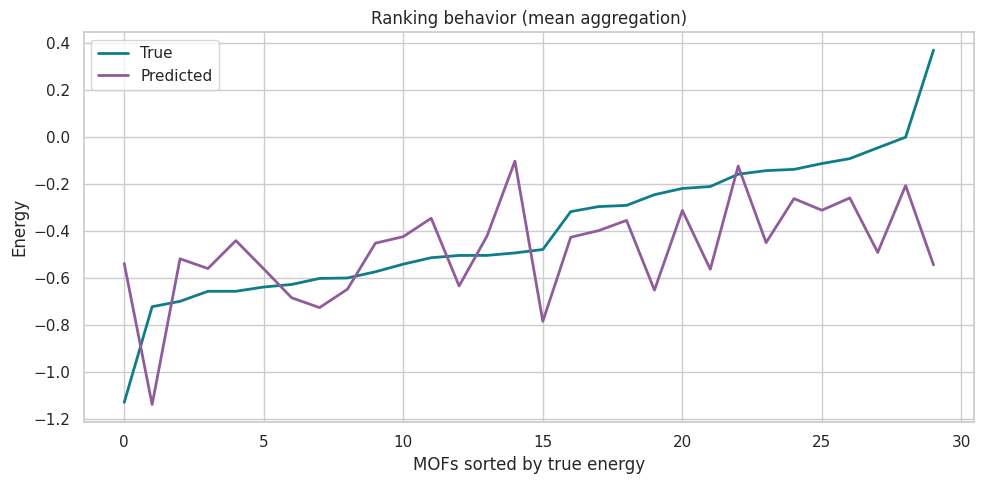

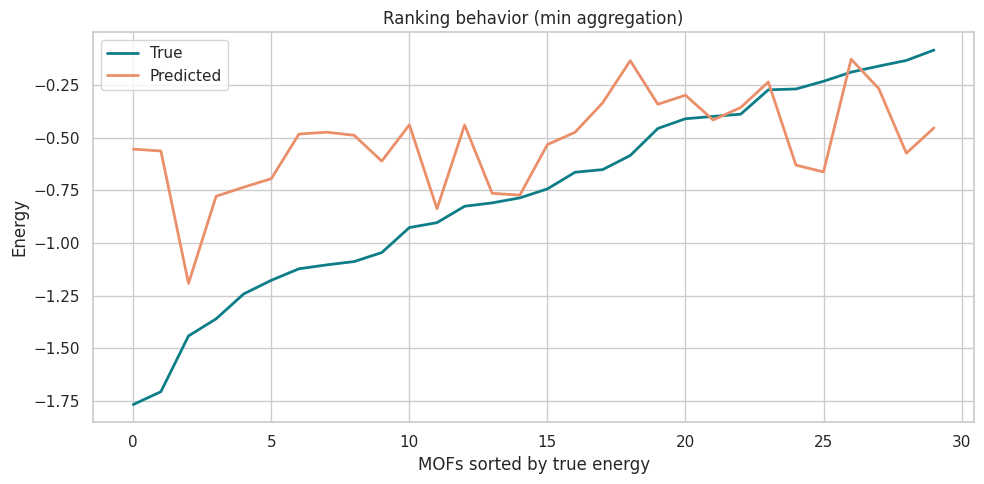

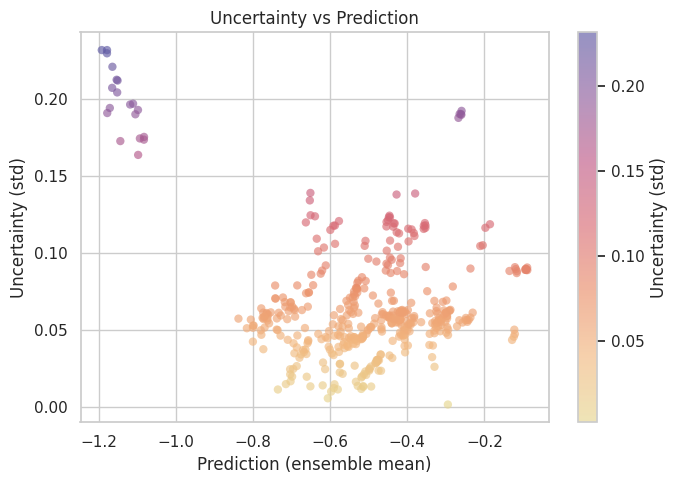

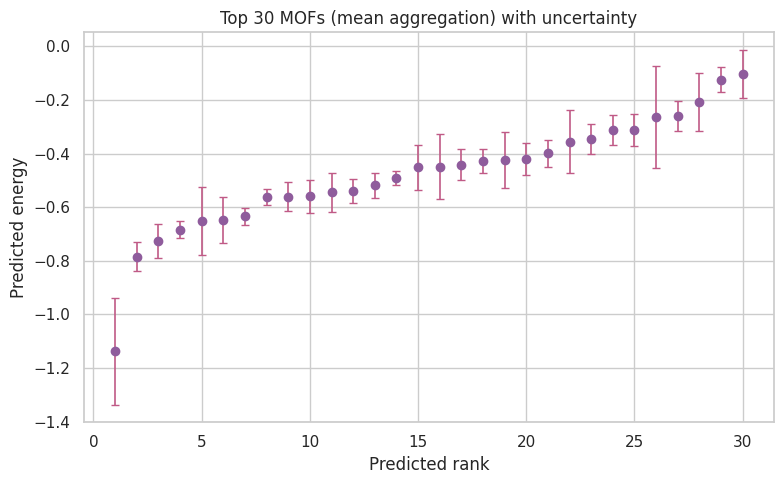

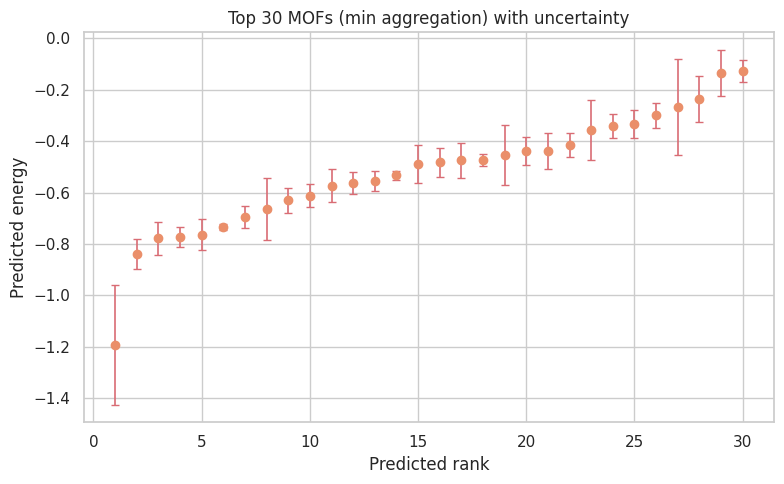


Top 15 test MOFs (mean aggregation):


,mof_name,y_true,y_pred,y_pred_std_mean,y_pred_std_max,n_configs,pred_rank
0,DAGDIZ,-0.721681,-1.137557,0.198468,0.231705,19,1
1,VUHJAK,-0.478531,-0.783945,0.054730,0.061458,19,2
2,XEHSIN_0.02_0,-0.601534,-0.725702,0.062981,0.079078,18,3
3,ja506357n_si_002_0.12_0,-0.627155,-0.683709,0.031393,0.051521,20,4
4,HAXMUP,-0.245478,-0.651260,0.128374,0.139098,5,5
5,jz4002345_si_002,-0.599658,-0.647114,0.085950,0.120854,23,6
6,ATOWIQ_0.16_1,-0.503844,-0.633542,0.032092,0.068161,19,7
7,RILVOZ,-0.210866,-0.562746,0.029307,0.049531,15,8
8,JOFKIA,-0.638032,-0.561029,0.054775,0.066111,16,9
9,ATOWIQ_0.16_0,-0.656274,-0.559445,0.062771,0.108018,18,10



Top 15 test MOFs (min aggregation):


,mof_name,y_true,y_pred,y_pred_std_at_best_config,n_configs,pred_rank
0,DAGDIZ,-1.441011,-1.191846,0.231705,19,1
1,VUHJAK,-0.903523,-0.837590,0.057601,19,2
2,XEHSIN_0.02_0,-1.360008,-0.778407,0.064255,18,3
3,jz4002345_si_002,-0.786088,-0.773051,0.037782,23,4
4,ATOWIQ_0.16_1,-0.809744,-0.764376,0.060691,19,5
5,ja506357n_si_002_0.12_0,-1.241694,-0.735356,0.011665,20,6
6,ATOWIQ_0.16_0,-1.177057,-0.694788,0.041635,18,7
7,HAXMUP,-0.232833,-0.662858,0.119982,5,8
8,RILVOZ,-0.269434,-0.630673,0.047656,15,9
9,JOFKIA,-1.045569,-0.611647,0.045710,16,10


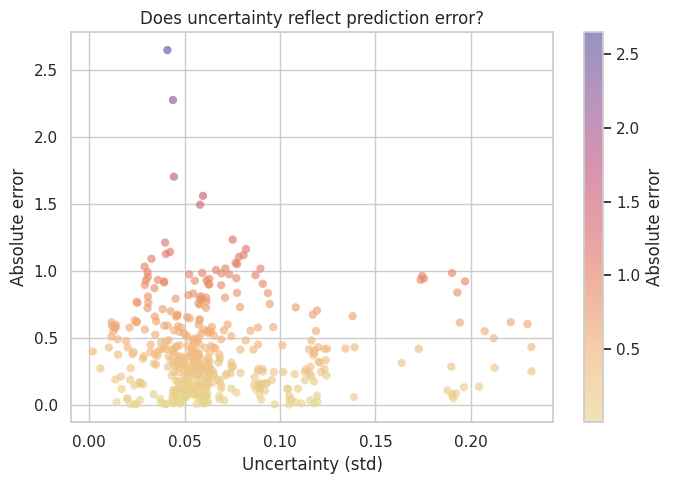

Spearman corr (uncertainty vs error): -0.0613
Pearson corr (uncertainty vs error): -0.0263


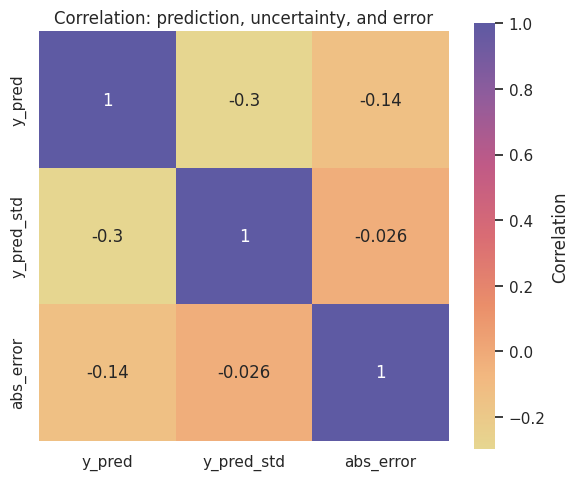

In [ ]:
# 15) PLOTS + SCREENING VISUALS (SUNSET PALETTE, GRAPH-SPECIFIC)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# =========================
# LOAD DATA
# =========================
OUT_DIR = "/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble"

hist_df = pd.read_csv(f"{OUT_DIR}/training_history_ensemble.csv")

val_mof_mean_df = pd.read_csv(f"{OUT_DIR}/val_mof_rankings_mean_ensemble.csv")
val_mof_min_df  = pd.read_csv(f"{OUT_DIR}/val_mof_rankings_min_ensemble.csv")
test_mof_mean_df = pd.read_csv(f"{OUT_DIR}/test_mof_rankings_mean_ensemble.csv")
test_mof_min_df  = pd.read_csv(f"{OUT_DIR}/test_mof_rankings_min_ensemble.csv")

val_config_df  = pd.read_csv(f"{OUT_DIR}/val_config_predictions_ensemble.csv")
test_config_df = pd.read_csv(f"{OUT_DIR}/test_config_predictions_ensemble.csv")

# =========================
# SUNSET PALETTE
# =========================
SUNSET = [
    "#e6d690",  # light yellow
    "#f2b880",  # warm orange
    "#ea8f6a",  # coral
    "#d96c74",  # soft red
    "#c05a86",  # rose
    "#8f5c9c",  # purple
    "#5e5aa3",  # deep indigo
]

# semantic assignments
TRUE_COLOR = "#0d7d87"     # teal for ground truth
PRED_COLOR = "#8f5c9c"     # purple for prediction
ALT_PRED   = "#ea8f6a"     # coral for alternate prediction emphasis
MSE_COLOR  = "#f2b880"     # warm orange
RANK_COLOR = "#d96c74"     # soft red
LOSS_COLOR = "#5e5aa3"     # deep indigo
TOP_COLOR  = "#8f5c9c"     # top-ranked group
BOTTOM_COLOR = "#ea8f6a"   # bottom-ranked group

SUNSET_CMAP = LinearSegmentedColormap.from_list("sunset_custom", SUNSET)

sns.set_theme(style="whitegrid")

# =========================
# 1. TRAINING CURVES
# categorical by ensemble member, but same metric -> use one hue family
# =========================
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

member_ids = sorted(hist_df["member_id"].unique())
loss_palette = sns.light_palette(LOSS_COLOR, n_colors=len(member_ids), reverse=False)
mse_palette  = sns.light_palette(MSE_COLOR, n_colors=len(member_ids), reverse=False)
rank_palette = sns.light_palette(RANK_COLOR, n_colors=len(member_ids), reverse=False)

sns.lineplot(
    data=hist_df, x="epoch", y="train_loss",
    hue="member_id", palette=loss_palette, ax=ax[0], legend=False
)
ax[0].set_title("Training total loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")

sns.lineplot(
    data=hist_df, x="epoch", y="train_mse_term",
    hue="member_id", palette=mse_palette, ax=ax[1], legend=False
)
ax[1].set_title("Training MSE term")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE term")

sns.lineplot(
    data=hist_df, x="epoch", y="train_rank_term",
    hue="member_id", palette=rank_palette, ax=ax[2], legend=False
)
ax[2].set_title("Training ranking term")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Ranking term")

plt.tight_layout()
plt.show()

# =========================
# 2. VALIDATION METRIC CURVES
# categorical by ensemble member, one distinct base color per metric
# =========================
metric_cols = [
    "val_min_Spearman",
    "val_min_Kendall",
    "val_min_RMSE",
    "val_min_MAE"
]
metric_base_colors = {
    "val_min_Spearman": "#5e5aa3",  # deep indigo
    "val_min_Kendall":  "#8f5c9c",  # purple
    "val_min_RMSE":     "#d96c74",  # soft red
    "val_min_MAE":      "#ea8f6a",  # coral
}

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.ravel()

for i, col in enumerate(metric_cols):
    palette_i = sns.light_palette(metric_base_colors[col], n_colors=len(member_ids), reverse=False)
    sns.lineplot(
        data=hist_df, x="epoch", y=col,
        hue="member_id", palette=palette_i, ax=ax[i], legend=False
    )
    ax[i].set_title(col.replace("_", " "))
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel(col.split("_")[-1])

plt.tight_layout()
plt.show()

# =========================
# 3. PARITY PLOTS (MOF-LEVEL)
# continuous relationship -> single clean prediction color + true parity line
# =========================
def parity_plot(df, title, point_color=PRED_COLOR):
    plt.figure(figsize=(6, 6))
    plt.scatter(df["y_true"], df["y_pred"], color=point_color, alpha=0.75, edgecolors="none")

    mn = min(df["y_true"].min(), df["y_pred"].min())
    mx = max(df["y_true"].max(), df["y_pred"].max())

    plt.plot([mn, mx], [mn, mx], color=TRUE_COLOR, linestyle="--", linewidth=1.5)
    plt.xlabel("True energy")
    plt.ylabel("Predicted energy")
    plt.title(title)
    plt.tight_layout()
    plt.show()

parity_plot(test_mof_mean_df, "Test MOF-level parity (mean aggregation)", point_color=PRED_COLOR)
parity_plot(test_mof_min_df,  "Test MOF-level parity (min aggregation)", point_color=ALT_PRED)

# =========================
# 4. RANKING PLOTS
# categorical comparison -> true vs predicted
# =========================
def ranking_plot(df, title, pred_color=PRED_COLOR):
    df2 = df.sort_values("y_true", ascending=True).reset_index(drop=True)

    plt.figure(figsize=(10, 5))
    plt.plot(df2.index, df2["y_true"], color=TRUE_COLOR, label="True", linewidth=2)
    plt.plot(df2.index, df2["y_pred"], color=pred_color, label="Predicted", linewidth=2)

    plt.xlabel("MOFs sorted by true energy")
    plt.ylabel("Energy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

ranking_plot(test_mof_mean_df, "Ranking behavior (mean aggregation)", pred_color=PRED_COLOR)
ranking_plot(test_mof_min_df,  "Ranking behavior (min aggregation)", pred_color=ALT_PRED)

# =========================
# 5. UNCERTAINTY VS PREDICTION
# sequential -> color by uncertainty using Sunset gradient
# =========================
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    test_config_df["y_pred"],
    test_config_df["y_pred_std"],
    c=test_config_df["y_pred_std"],
    cmap=SUNSET_CMAP,
    alpha=0.65,
    edgecolors="none"
)
plt.colorbar(sc, label="Uncertainty (std)")
plt.xlabel("Prediction (ensemble mean)")
plt.ylabel("Uncertainty (std)")
plt.title("Uncertainty vs Prediction")
plt.tight_layout()
plt.show()

# =========================
# 6. MOF-LEVEL UNCERTAINTY
# ranked candidates -> categorical emphasis for mean vs min
# =========================
if "y_pred_std_mean" in test_mof_mean_df.columns:
    plt.figure(figsize=(8, 5))
    tmp = test_mof_mean_df.sort_values("pred_rank").head(30)

    plt.errorbar(
        x=tmp["pred_rank"],
        y=tmp["y_pred"],
        yerr=tmp["y_pred_std_mean"],
        fmt="o",
        color=PRED_COLOR,
        ecolor="#c05a86",
        elinewidth=1.2,
        capsize=3
    )
    plt.xlabel("Predicted rank")
    plt.ylabel("Predicted energy")
    plt.title("Top 30 MOFs (mean aggregation) with uncertainty")
    plt.tight_layout()
    plt.show()

if "y_pred_std_at_best_config" in test_mof_min_df.columns:
    plt.figure(figsize=(8, 5))
    tmp = test_mof_min_df.sort_values("pred_rank").head(30)

    plt.errorbar(
        x=tmp["pred_rank"],
        y=tmp["y_pred"],
        yerr=tmp["y_pred_std_at_best_config"],
        fmt="o",
        color=ALT_PRED,
        ecolor="#d96c74",
        elinewidth=1.2,
        capsize=3
    )
    plt.xlabel("Predicted rank")
    plt.ylabel("Predicted energy")
    plt.title("Top 30 MOFs (min aggregation) with uncertainty")
    plt.tight_layout()
    plt.show()

# =========================
# 7. TOP MOFs TABLE
# =========================
print("\nTop 15 test MOFs (mean aggregation):")
display(test_mof_mean_df.head(15))

print("\nTop 15 test MOFs (min aggregation):")
display(test_mof_min_df.head(15))

# =========================
# 8. UNCERTAINTY VS ERROR
# sequential -> color by abs error using Sunset gradient
# =========================
test_config_df["abs_error"] = (test_config_df["y_true"] - test_config_df["y_pred"]).abs()

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    test_config_df["y_pred_std"],
    test_config_df["abs_error"],
    c=test_config_df["abs_error"],
    cmap=SUNSET_CMAP,
    alpha=0.65,
    edgecolors="none"
)
plt.colorbar(sc, label="Absolute error")
plt.xlabel("Uncertainty (std)")
plt.ylabel("Absolute error")
plt.title("Does uncertainty reflect prediction error?")
plt.tight_layout()
plt.show()

corr_s = test_config_df[["y_pred_std", "abs_error"]].corr(method="spearman").iloc[0, 1]
corr_p = test_config_df[["y_pred_std", "abs_error"]].corr(method="pearson").iloc[0, 1]

print(f"Spearman corr (uncertainty vs error): {corr_s:.4f}")
print(f"Pearson corr (uncertainty vs error): {corr_p:.4f}")


Come back and check Early stopping Tab - MSE Loss/Pairwise ranking and Mean predictions. possibly aggregation

#Confidence Interval

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base = "/content/drive/MyDrive/MOF_Conf"

for root, dirs, files in os.walk(base):
    for f in files:
        if "ranking" in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/MOF_Conf/egnn_results/test_mof_rankings_mean.csv
/content/drive/MyDrive/MOF_Conf/egnn_results/test_mof_rankings_min.csv
/content/drive/MyDrive/MOF_Conf/egnn_results/val_mof_rankings_mean.csv
/content/drive/MyDrive/MOF_Conf/egnn_results/val_mof_rankings_min.csv
/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble/test_mof_rankings_min_ensemble.csv
/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble/val_mof_rankings_min_ensemble.csv
/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble/val_mof_rankings_mean_ensemble.csv
/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble/test_mof_rankings_mean_ensemble.csv


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, kendalltau

# =========================
# CONFIG
# =========================
N_BOOT = 2000
TOP_K = 10
SEED = 42

# =========================
# METRICS
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def compute_metrics(df, k=10):
    y_true = df["y_true"].values
    y_pred = df["y_pred"].values

    # basic metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse_val = rmse(y_true, y_pred)

    sp = spearmanr(y_true, y_pred).correlation
    kt = kendalltau(y_true, y_pred).correlation

    sp = np.nan if sp is None else sp
    kt = np.nan if kt is None else kt

    # top-k recall
    k = min(k, len(df))
    true_top = set(df.nsmallest(k, "y_true")["mof_name"])
    pred_top = set(df.nsmallest(k, "y_pred")["mof_name"])
    recall = len(true_top & pred_top) / k

    return {
        "MAE": mae,
        "RMSE": rmse_val,
        "Spearman": sp,
        "Kendall": kt,
        f"Top{k}_Recall": recall
    }

# =========================
# BOOTSTRAP
# =========================
def bootstrap_ci(df, n_boot=2000, k=10, seed=42):
    rng = np.random.default_rng(seed)
    n = len(df)

    results = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = df.iloc[idx].reset_index(drop=True)

        metrics = compute_metrics(sample, k=k)
        results.append(metrics)

    boot_df = pd.DataFrame(results)

    # point estimate
    point = compute_metrics(df, k=k)

    summary = []
    for col in boot_df.columns:
        vals = boot_df[col].dropna().values
        lo, hi = np.percentile(vals, [2.5, 97.5])

        summary.append({
            "metric": col,
            "point": point[col],
            "ci_lower": lo,
            "ci_upper": hi
        })

    return pd.DataFrame(summary), boot_df

# =========================
# LOAD YOUR FILES
# =========================
OUT_DIR = "/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble"

df_mean = pd.read_csv(f"{OUT_DIR}/test_mof_rankings_mean_ensemble.csv")
df_min  = pd.read_csv(f"{OUT_DIR}/test_mof_rankings_min_ensemble.csv")

# =========================
# RUN BOOTSTRAP
# =========================
summary_mean, boot_mean = bootstrap_ci(df_mean, n_boot=N_BOOT, k=TOP_K, seed=SEED)
summary_min, boot_min   = bootstrap_ci(df_min,  n_boot=N_BOOT, k=TOP_K, seed=SEED)

# =========================
# PRINT CLEAN RESULTS
# =========================
def print_results(summary, title):
    print(f"\n{title}")
    print("=" * len(title))
    for _, row in summary.iterrows():
        print(f"{row['metric']}: {row['point']:.3f} "
              f"[{row['ci_lower']:.3f}, {row['ci_upper']:.3f}]")

print_results(summary_mean, "TEST (mean aggregation) - Bootstrap CI")
print_results(summary_min,  "TEST (min aggregation) - Bootstrap CI")

# =========================
# SAVE RESULTS
# =========================
summary_mean.to_csv(f"{OUT_DIR}/bootstrap_ci_mean.csv", index=False)
summary_min.to_csv(f"{OUT_DIR}/bootstrap_ci_min.csv", index=False)


TEST (mean aggregation) - Bootstrap CI
MAE: 0.221 [0.159, 0.296]
RMSE: 0.291 [0.196, 0.388]
Spearman: 0.496 [0.181, 0.722]
Kendall: 0.361 [0.130, 0.572]
Top10_Recall: 0.600 [0.200, 0.600]

TEST (min aggregation) - Bootstrap CI
MAE: 0.357 [0.253, 0.470]
RMSE: 0.465 [0.330, 0.594]
Spearman: 0.519 [0.179, 0.744]
Kendall: 0.379 [0.156, 0.586]
Top10_Recall: 0.500 [0.200, 0.600]


#Interpretability

Loaded ranking file: /content/drive/MyDrive/MOF_Conf/egnn_results_ensemble/test_mof_rankings_min_ensemble.csv
           mof_name    y_true    y_pred  y_pred_std_at_best_config  n_configs  \
0            DAGDIZ -1.441011 -1.191846                   0.231705         19   
1            VUHJAK -0.903523 -0.837590                   0.057601         19   
2     XEHSIN_0.02_0 -1.360008 -0.778407                   0.064255         18   
3  jz4002345_si_002 -0.786088 -0.773051                   0.037782         23   
4     ATOWIQ_0.16_1 -0.809744 -0.764376                   0.060691         19   

   pred_rank  
0          1  
1          2  
2          3  
3          4  
4          5  
Loading cached structural feature tables...
Config-level feature shape: (444, 60)
MOF-level feature shape: (30, 234)
Merged shape: (30, 239)

Top group MOFs:
['DAGDIZ', 'VUHJAK', 'XEHSIN_0.02_0', 'jz4002345_si_002', 'ATOWIQ_0.16_1', 'ja506357n_si_002_0.12_0', 'ATOWIQ_0.16_0', 'HAXMUP', 'RILVOZ', 'JOFKIA', 'ATOWI

,feature,top_mean,bottom_mean,top_median,bottom_median,p_value
7,pairwise_std_dist__mean,4.808822,5.793600,4.261687,5.128454,0.031437
6,pairwise_mean_dist__mean,10.999504,12.774783,10.094426,11.608025,0.056401
0,n_atoms__mean,194.693737,257.330866,183.275000,235.500000,0.090756
13,frac_C__mean,0.352875,0.388898,0.394734,0.423609,0.155376
18,frac_Cu__mean,0.021278,0.009580,0.000000,0.000000,0.159918
9,coord_mean__mean,6.029433,6.330896,5.867851,6.284327,0.189336
11,coord_max__mean,11.155245,12.251003,10.925000,11.000000,0.260900
8,pairwise_min_dist__mean,0.990918,0.997144,0.981786,0.990949,0.336689
20,frac_Zr__mean,0.002493,0.000000,0.000000,0.000000,0.342112
5,max_element_fraction__mean,0.416321,0.430537,0.412933,0.430306,0.364617



Group summary:


rank_group                             Bottom         Top
n_atoms__mean              mean    257.330866  194.693737
                           median  235.500000  183.275000
                           std     113.290687  100.798715
avg_atomic_number__mean    mean      7.064550    6.673374
                           median    6.371016    6.012541
                           std       1.740827    1.550283
std_atomic_number__mean    mean      7.297458    6.575925
                           median    6.526104    5.829499
                           std       2.794584    2.524639
frac_metal__mean           mean      0.061420    0.058006
                           median    0.048475    0.047264
                           std       0.034772    0.034870
n_unique_elements__mean    mean      5.050000    4.900000
                           median    5.000000    5.000000
                           std       0.510418    0.640723
max_element_fraction__mean mean      0.430537    0.416321
                           median    0.430306    0.412933
                           std       0.063589    0.068493
pairwise_mean_dist__mean   mean     12.774783   10.999504
                           median   11.608025   10.094426


Z-shift summary:


,feature,top_group_zshift,bottom_group_zshift
0,n_atoms__mean,-0.683801,0.341901
1,avg_atomic_number__mean,-0.281252,0.140626
2,std_atomic_number__mean,-0.264314,0.132157
3,frac_metal__mean,-0.076976,0.038488
4,n_unique_elements__mean,-0.547723,0.273861
5,max_element_fraction__mean,-0.471835,0.235917
6,pairwise_mean_dist__mean,-0.717020,0.358510
7,pairwise_std_dist__mean,-0.701397,0.350699
8,pairwise_min_dist__mean,-0.121409,0.060705
9,coord_mean__mean,-0.359741,0.179871


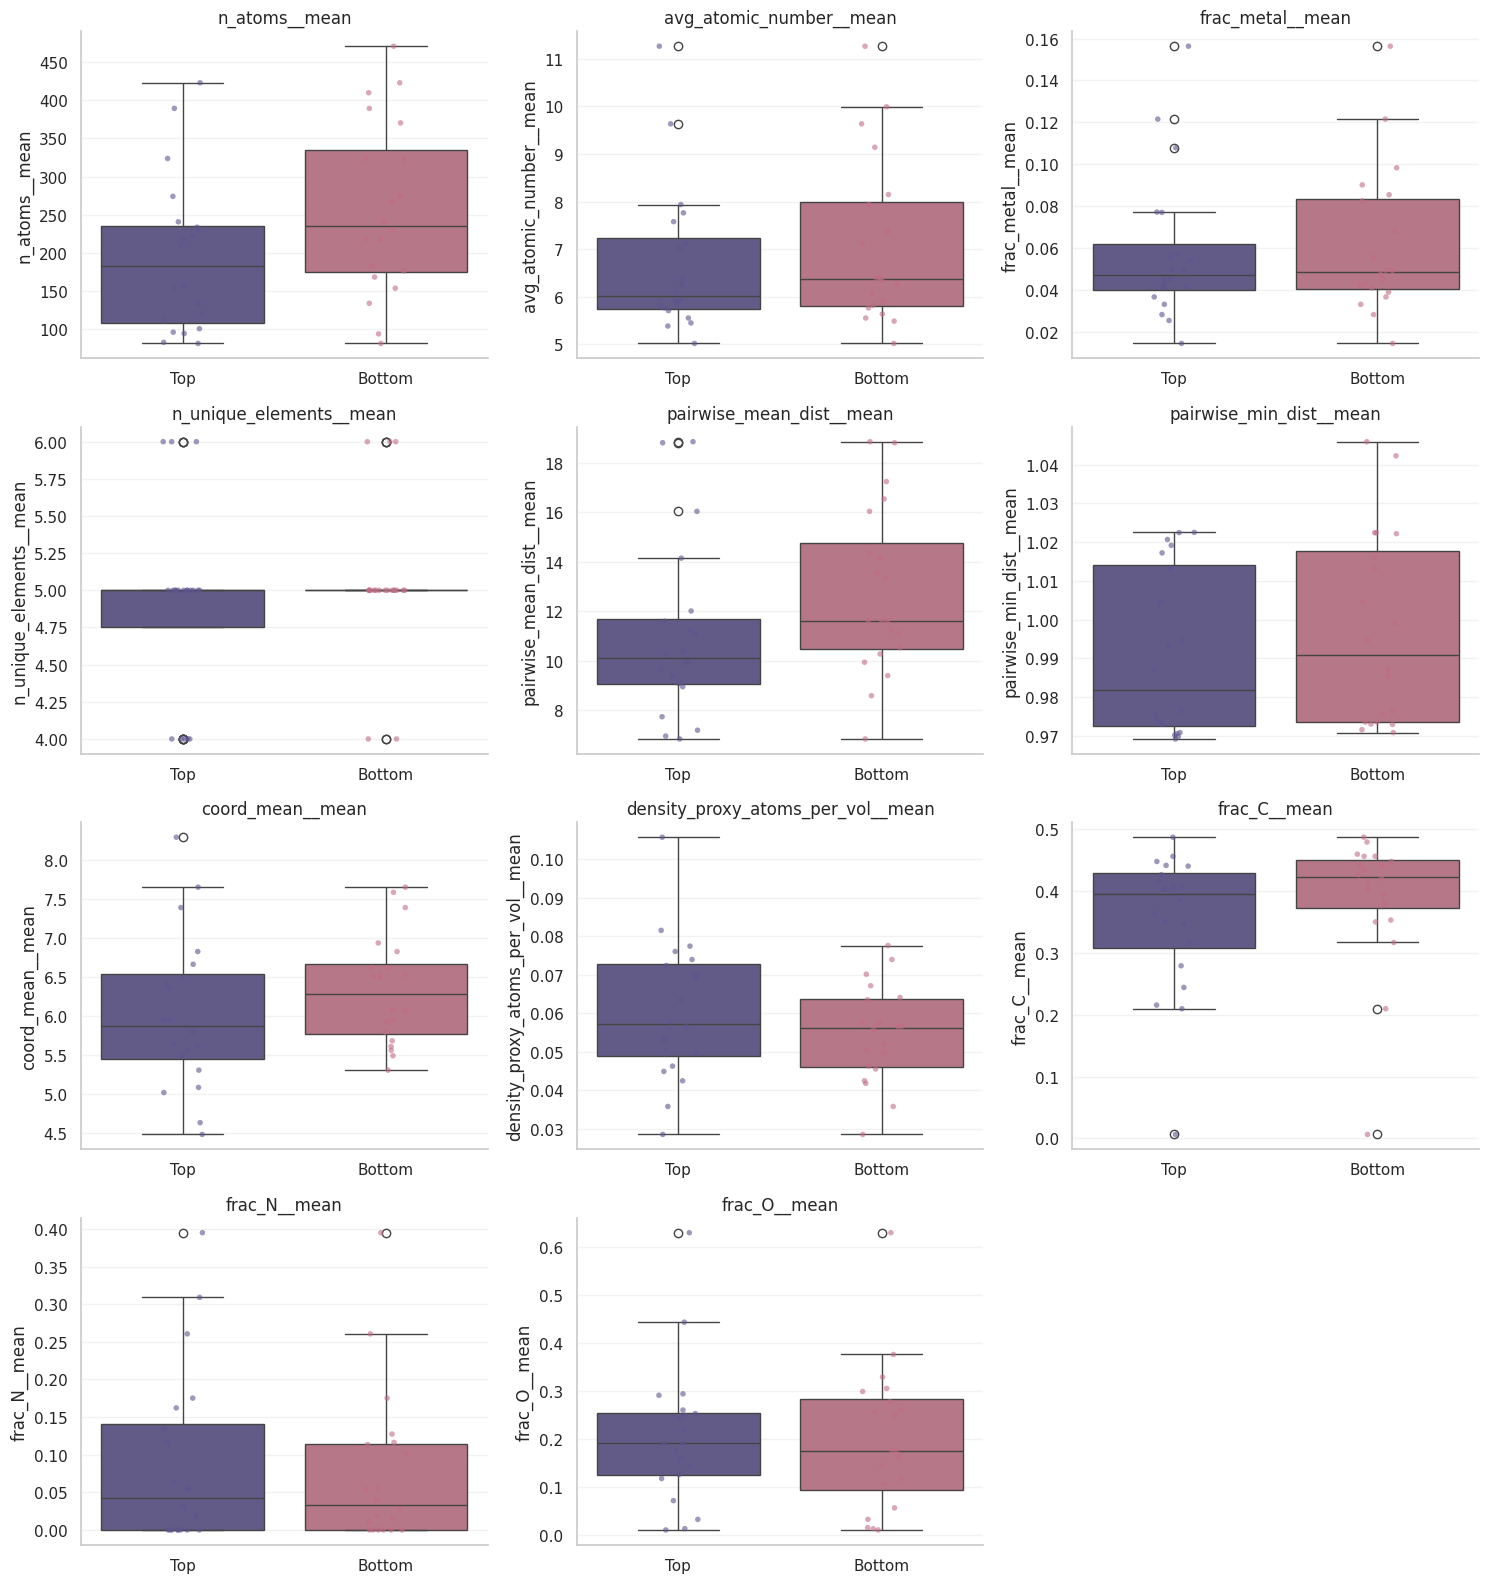

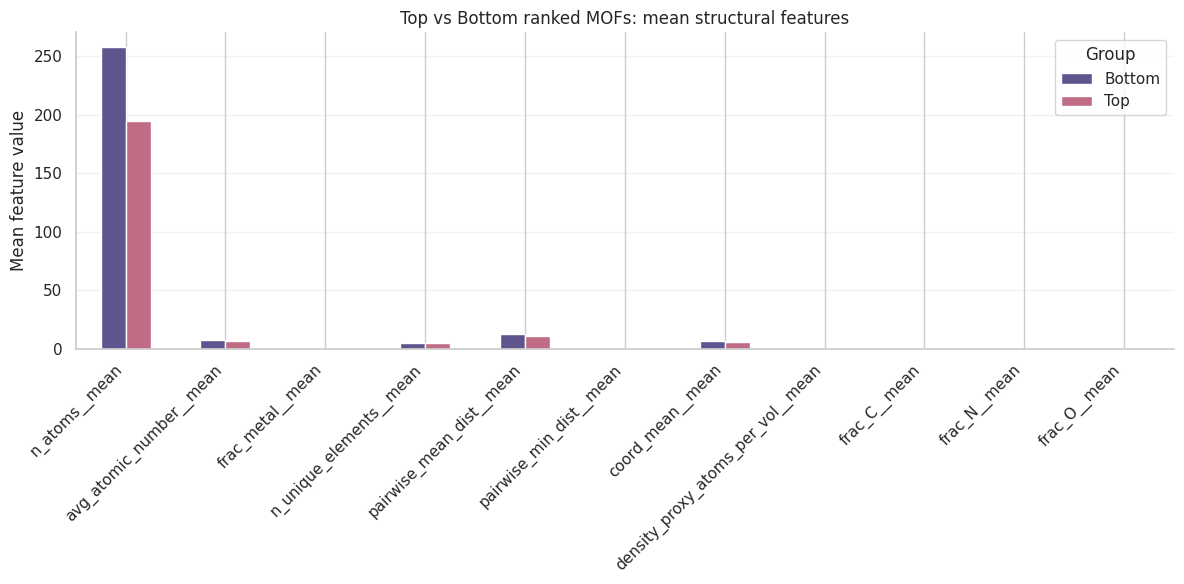


Normalized comparison:


,feature,top_mean,bottom_mean,top_vs_all_z,bottom_vs_all_z
1,avg_atomic_number__mean,6.673374,7.064550,-0.115991,0.140626
6,coord_mean__mean,6.029433,6.330896,-0.160093,0.179871
7,density_proxy_atoms_per_vol__mean,0.060367,0.054610,0.032994,-0.327797
8,frac_C__mean,0.352875,0.388898,-0.203024,0.155101
9,frac_N__mean,0.088798,0.075543,0.148715,0.018057
10,frac_O__mean,0.206329,0.199932,-0.033113,-0.079775
2,frac_metal__mean,0.058006,0.061420,-0.071203,0.038488
0,n_atoms__mean,194.693737,257.330866,-0.218508,0.341901
3,n_unique_elements__mean,4.900000,5.050000,0.000000,0.273861
4,pairwise_mean_dist__mean,10.999504,12.774783,-0.171748,0.358510



Saved structure–property analysis outputs to: /content/drive/MyDrive/MOF_Conf/egnn_results_ensemble


In [ ]:
# 16) STRUCTURE–PROPERTY ANALYSIS: TOP- VS BOTTOM-RANKED MOFs

import math
import json
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")


# ============================================================
# REQUIRED PATH FIX
# Make sure OUT_DIR and TEST_DIR behave like pathlib.Path objects
# ============================================================
OUT_DIR = Path(OUT_DIR)
TEST_DIR = Path(TEST_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# "min" is often more meaningful for adsorption screening
RANKING_MODE = "min"   # options: "min" or "mean"

# How many top and bottom MOFs to compare
TOP_K = 20
BOTTOM_K = 20

# Feature cutoffs
COORD_CUTOFF = 3.0      # local coordination proxy
PAIRWISE_SAMPLE_LIMIT = 400  # if too many atoms, sample for pairwise distances

# Metals list (simple periodic-table based grouping)
METAL_ATOMIC_NUMBERS = set([
    3, 4, 11, 12, 13,
    19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31,
    37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
    55, 56,
    72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88,
    104, 105, 106, 107, 108, 109, 110, 111, 112
])

# Common atom types to track explicitly in MOFs
ELEMENT_MAP = {
    1: "H",
    6: "C",
    7: "N",
    8: "O",
    9: "F",
    14: "Si",
    15: "P",
    16: "S",
    17: "Cl",
    26: "Fe",
    29: "Cu",
    30: "Zn",
    13: "Al",
    22: "Ti",
    27: "Co",
    28: "Ni",
    40: "Zr",
    42: "Mo",
    46: "Pd",
    47: "Ag",
}

TOP_COLOR = "#5E548E"      # purple
BOTTOM_COLOR = "#C06C84"   # rose


# ============================================================
# HELPERS
# ============================================================
def safe_tensor_to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def get_cell_volume(graph):
    """
    Try to extract cell volume if present.
    Returns np.nan if unavailable.
    """
    possible_attrs = ["cell", "lattice"]
    for attr in possible_attrs:
        if hasattr(graph, attr):
            val = getattr(graph, attr)
            arr = safe_tensor_to_numpy(val)

            try:
                arr = np.asarray(arr, dtype=float)
                if arr.shape == (3, 3):
                    return float(abs(np.linalg.det(arr)))
                if arr.ndim == 3 and arr.shape[-2:] == (3, 3):
                    return float(abs(np.linalg.det(arr[0])))
            except Exception:
                pass
    return np.nan

def estimate_pairwise_stats(pos, sample_limit=400):
    """
    Compute pairwise distance stats.
    For large graphs, subsample atoms to control cost.
    """
    n = pos.shape[0]
    if n < 2:
        return {
            "pairwise_mean_dist": np.nan,
            "pairwise_std_dist": np.nan,
            "pairwise_min_dist": np.nan,
            "pairwise_max_dist": np.nan,
        }

    if n > sample_limit:
        idx = np.random.choice(n, size=sample_limit, replace=False)
        pos_use = pos[idx]
    else:
        pos_use = pos

    d = pdist(pos_use)
    if len(d) == 0:
        return {
            "pairwise_mean_dist": np.nan,
            "pairwise_std_dist": np.nan,
            "pairwise_min_dist": np.nan,
            "pairwise_max_dist": np.nan,
        }

    return {
        "pairwise_mean_dist": float(np.mean(d)),
        "pairwise_std_dist": float(np.std(d)),
        "pairwise_min_dist": float(np.min(d)),
        "pairwise_max_dist": float(np.max(d)),
    }

def coordination_stats_from_pos(pos, cutoff=3.0):
    """
    Simple geometric coordination proxy from coordinates only.
    Counts neighbors within cutoff (excluding self).
    """
    n = pos.shape[0]
    if n <= 1:
        return {
            "coord_mean": np.nan,
            "coord_std": np.nan,
            "coord_max": np.nan,
        }

    dmat = np.linalg.norm(pos[:, None, :] - pos[None, :, :], axis=-1)
    neigh = (dmat < cutoff).astype(int)
    np.fill_diagonal(neigh, 0)
    coord = neigh.sum(axis=1)

    return {
        "coord_mean": float(np.mean(coord)),
        "coord_std": float(np.std(coord)),
        "coord_max": float(np.max(coord)),
    }

def graph_density_proxy(n_atoms, volume):
    if np.isnan(volume) or volume <= 0:
        return np.nan
    return float(n_atoms / volume)

def compute_graph_structural_features(graph):
    """
    Uses only graph-level information already available:
    - pos
    - z
    - edge_index if present (not required)
    - optional cell/lattice if available

    Returns config-level feature dict.
    """
    pos = safe_tensor_to_numpy(graph.pos).astype(float)
    z = safe_tensor_to_numpy(graph.z).astype(int)

    n_atoms = int(len(z))
    atom_counter = Counter(z)

    metals_mask = np.array([int(a in METAL_ATOMIC_NUMBERS) for a in z], dtype=int)
    nonmetals_mask = 1 - metals_mask

    avg_atomic_number = float(np.mean(z)) if n_atoms > 0 else np.nan
    std_atomic_number = float(np.std(z)) if n_atoms > 0 else np.nan
    frac_metal = float(np.mean(metals_mask)) if n_atoms > 0 else np.nan
    n_metal = int(metals_mask.sum())
    n_nonmetal = int(nonmetals_mask.sum())

    cell_volume = get_cell_volume(graph)
    density_proxy = graph_density_proxy(n_atoms, cell_volume)

    pair_stats = estimate_pairwise_stats(pos, sample_limit=PAIRWISE_SAMPLE_LIMIT)
    coord_stats = coordination_stats_from_pos(pos, cutoff=COORD_CUTOFF)

    feat = {
        "n_atoms": n_atoms,
        "avg_atomic_number": avg_atomic_number,
        "std_atomic_number": std_atomic_number,
        "n_metal": n_metal,
        "n_nonmetal": n_nonmetal,
        "frac_metal": frac_metal,
        "cell_volume": cell_volume,
        "density_proxy_atoms_per_vol": density_proxy,
    }

    feat.update(pair_stats)
    feat.update(coord_stats)

    # explicit common element counts + fractions
    for atomic_num, symbol in ELEMENT_MAP.items():
        count = atom_counter.get(atomic_num, 0)
        feat[f"count_{symbol}"] = int(count)
        feat[f"frac_{symbol}"] = float(count / n_atoms) if n_atoms > 0 else np.nan

    # chemistry diversity
    feat["n_unique_elements"] = int(len(atom_counter))
    feat["max_element_fraction"] = float(max(atom_counter.values()) / n_atoms) if n_atoms > 0 else np.nan

    return feat

def extract_name(value):
    """
    Safely convert attribute values that may come as Python object, list, tuple, tensor-wrapped string, etc.
    """
    if isinstance(value, (list, tuple)):
        if len(value) == 1:
            return str(value[0])
        return str(value)
    return str(value)

def gather_config_features_from_chunks(chunk_dir):
    """
    Loads all .pt files in a split directory and computes per-config structural features.
    Expects each graph to have mof_name and optionally config_name / sample_name.
    """
    rows = []

    pt_files = sorted(Path(chunk_dir).glob("*.pt"))
    print(f"Found {len(pt_files)} chunk files in {chunk_dir}")

    for pt_file in pt_files:
        print(f"Loading {pt_file.name}")
        data_list = torch.load(pt_file, map_location="cpu")

        for graph in data_list:
            mof_name = extract_name(getattr(graph, "mof_name", "UNKNOWN_MOF"))

            if hasattr(graph, "config_name"):
                config_name = extract_name(graph.config_name)
            elif hasattr(graph, "sample_name"):
                config_name = extract_name(graph.sample_name)
            elif hasattr(graph, "name"):
                config_name = extract_name(graph.name)
            else:
                config_name = None

            feat = compute_graph_structural_features(graph)
            feat["mof_name"] = mof_name
            feat["config_name"] = config_name

            if hasattr(graph, "y"):
                try:
                    feat["y_true"] = float(safe_tensor_to_numpy(graph.y).reshape(-1)[0])
                except Exception:
                    feat["y_true"] = np.nan
            else:
                feat["y_true"] = np.nan

            rows.append(feat)

    df = pd.DataFrame(rows)
    print(f"Built config-level feature table: {df.shape}")
    return df

def aggregate_features_to_mof(config_feat_df):
    """
    Aggregate config-level structure features to MOF-level.
    Since each MOF may have multiple configurations, we summarize across configs.
    """
    numeric_cols = [c for c in config_feat_df.columns if c not in ["mof_name", "config_name"]]

    agg_dict = {}
    for c in numeric_cols:
        agg_dict[c] = ["mean", "std", "min", "max"]

    mof_df = config_feat_df.groupby("mof_name").agg(agg_dict)
    mof_df.columns = ["__".join(col).strip() for col in mof_df.columns]
    mof_df = mof_df.reset_index()

    # Also add how many configs per MOF were available
    counts = config_feat_df.groupby("mof_name").size().reset_index(name="n_configs_feature_table")
    mof_df = mof_df.merge(counts, on="mof_name", how="left")

    return mof_df

def pick_top_bottom_groups(ranking_df, top_k=20, bottom_k=20):
    ranking_df = ranking_df.sort_values("pred_rank", ascending=True).reset_index(drop=True)
    top_df = ranking_df.head(top_k).copy()
    bottom_df = ranking_df.tail(bottom_k).copy()

    top_df["rank_group"] = "Top"
    bottom_df["rank_group"] = "Bottom"

    return pd.concat([top_df, bottom_df], axis=0).reset_index(drop=True)

def mannwhitney_table(df, group_col, feature_cols):
    rows = []
    top = df[df[group_col] == "Top"]
    bottom = df[df[group_col] == "Bottom"]

    for feat in feature_cols:
        x = top[feat].dropna().values
        y = bottom[feat].dropna().values

        if len(x) < 3 or len(y) < 3:
            rows.append({
                "feature": feat,
                "top_mean": np.nanmean(x) if len(x) > 0 else np.nan,
                "bottom_mean": np.nanmean(y) if len(y) > 0 else np.nan,
                "top_median": np.nanmedian(x) if len(x) > 0 else np.nan,
                "bottom_median": np.nanmedian(y) if len(y) > 0 else np.nan,
                "p_value": np.nan
            })
            continue

        try:
            stat, p = mannwhitneyu(x, y, alternative="two-sided")
        except Exception:
            p = np.nan

        rows.append({
            "feature": feat,
            "top_mean": float(np.mean(x)),
            "bottom_mean": float(np.mean(y)),
            "top_median": float(np.median(x)),
            "bottom_median": float(np.median(y)),
            "p_value": p
        })

    out = pd.DataFrame(rows).sort_values("p_value", na_position="last")
    return out

def plot_boxplots(group_df, features, group_col="rank_group", ncols=3):
    n = len(features)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    palette = {
        "Top": TOP_COLOR,
        "Bottom": BOTTOM_COLOR
    }

    for i, feat in enumerate(features):
        ax = axes[i]

        sns.boxplot(
            data=group_df,
            x=group_col,
            y=feat,
            hue=group_col,
            palette=palette,
            dodge=False,
            ax=ax,
            legend=False
        )

        sns.stripplot(
            data=group_df,
            x=group_col,
            y=feat,
            hue=group_col,
            palette=palette,
            dodge=False,
            alpha=0.6,
            size=4,
            ax=ax,
            legend=False
        )

        ax.set_title(feat)
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_grouped_bar_means(group_df, features, group_col="rank_group"):
    summary = group_df.groupby(group_col)[features].mean().T

    ax = summary.plot(
        kind="bar",
        figsize=(12, 6),
        color=[TOP_COLOR, BOTTOM_COLOR]
    )

    ax.set_ylabel("Mean feature value")
    ax.set_title("Top vs Bottom ranked MOFs: mean structural features")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Group")

    sns.despine()
    plt.tight_layout()
    plt.show()

def zscore_relative_to_all(merged_df, feature_cols):
    """
    Useful for an interpretable summary table:
    how top and bottom groups shift relative to full test-set MOF distribution.
    """
    rows = []
    for feat in feature_cols:
        all_vals = merged_df[feat].dropna()
        mu = all_vals.mean()
        sd = all_vals.std()

        top_mask = merged_df["rank_group"] == "Top"
        bottom_mask = merged_df["rank_group"] == "Bottom"

        if pd.isna(sd) or sd == 0:
            top_z = np.nan
            bottom_z = np.nan
        else:
            top_z = (merged_df.loc[top_mask, feat].mean() - mu) / sd if top_mask.any() else np.nan
            bottom_z = (merged_df.loc[bottom_mask, feat].mean() - mu) / sd if bottom_mask.any() else np.nan

        rows.append({
            "feature": feat,
            "top_group_zshift": top_z,
            "bottom_group_zshift": bottom_z
        })

    return pd.DataFrame(rows)


# 1) LOAD MOF-LEVEL RANKINGS
if RANKING_MODE == "min":
    ranking_path = OUT_DIR / "test_mof_rankings_min_ensemble.csv"
elif RANKING_MODE == "mean":
    ranking_path = OUT_DIR / "test_mof_rankings_mean_ensemble.csv"
else:
    raise ValueError("RANKING_MODE must be 'min' or 'mean'")

ranking_df = pd.read_csv(ranking_path)
print("Loaded ranking file:", ranking_path)
print(ranking_df.head())


# 2) BUILD CONFIG-LEVEL STRUCTURAL FEATURE TABLE FROM TEST CHUNKS
config_feature_path = OUT_DIR / "test_config_structural_features.csv"
mof_feature_path = OUT_DIR / "test_mof_structural_features.csv"

if config_feature_path.exists() and mof_feature_path.exists():
    print("Loading cached structural feature tables...")
    config_feat_df = pd.read_csv(config_feature_path)
    mof_feat_df = pd.read_csv(mof_feature_path)
else:
    config_feat_df = gather_config_features_from_chunks(TEST_DIR)
    mof_feat_df = aggregate_features_to_mof(config_feat_df)

    config_feat_df.to_csv(config_feature_path, index=False)
    mof_feat_df.to_csv(mof_feature_path, index=False)

print("Config-level feature shape:", config_feat_df.shape)
print("MOF-level feature shape:", mof_feat_df.shape)


# 3) MERGE STRUCTURAL FEATURES WITH RANKING OUTPUT
merged_df = ranking_df.merge(mof_feat_df, on="mof_name", how="inner")
print("Merged shape:", merged_df.shape)

# Select top and bottom ranked groups
group_df = pick_top_bottom_groups(merged_df, top_k=TOP_K, bottom_k=BOTTOM_K)

print("\nTop group MOFs:")
print(group_df[group_df["rank_group"] == "Top"]["mof_name"].tolist())

print("\nBottom group MOFs:")
print(group_df[group_df["rank_group"] == "Bottom"]["mof_name"].tolist())


# 4) CHOOSE FEATURES TO INTERPRET
feature_cols = [
    "n_atoms__mean",
    "avg_atomic_number__mean",
    "std_atomic_number__mean",
    "frac_metal__mean",
    "n_unique_elements__mean",
    "max_element_fraction__mean",
    "pairwise_mean_dist__mean",
    "pairwise_std_dist__mean",
    "pairwise_min_dist__mean",
    "coord_mean__mean",
    "coord_std__mean",
    "coord_max__mean",
    "density_proxy_atoms_per_vol__mean",
    "frac_C__mean",
    "frac_H__mean",
    "frac_N__mean",
    "frac_O__mean",
    "frac_Zn__mean",
    "frac_Cu__mean",
    "frac_Fe__mean",
    "frac_Zr__mean",
]

feature_cols = [c for c in feature_cols if c in group_df.columns]
print("\nUsing feature columns:")
print(feature_cols)


# 5) SUMMARY TABLES
summary_table = group_df.groupby("rank_group")[feature_cols].agg(["mean", "median", "std"]).T
summary_table.to_csv(OUT_DIR / f"structure_property_summary_{RANKING_MODE}.csv")

stats_table = mannwhitney_table(group_df, "rank_group", feature_cols)
stats_table.to_csv(OUT_DIR / f"structure_property_stats_{RANKING_MODE}.csv", index=False)

rank_map = dict(zip(group_df["mof_name"], group_df["rank_group"]))
merged_for_z = merged_df.copy()
merged_for_z["rank_group"] = merged_for_z["mof_name"].map(rank_map)

zshift_table = zscore_relative_to_all(merged_for_z, feature_cols)
zshift_table.to_csv(OUT_DIR / f"structure_property_zshift_{RANKING_MODE}.csv", index=False)

print("\nTop statistical differences:")
display(stats_table.head(15))

print("\nGroup summary:")
display(summary_table.head(20))

print("\nZ-shift summary:")
display(zshift_table.head(20))


# 6) PLOTS
plot_features = [
    c for c in [
        "n_atoms__mean",
        "avg_atomic_number__mean",
        "frac_metal__mean",
        "n_unique_elements__mean",
        "pairwise_mean_dist__mean",
        "pairwise_min_dist__mean",
        "coord_mean__mean",
        "density_proxy_atoms_per_vol__mean",
        "frac_C__mean",
        "frac_N__mean",
        "frac_O__mean",
    ] if c in group_df.columns
]

plot_boxplots(group_df, plot_features, group_col="rank_group", ncols=3)
plot_grouped_bar_means(group_df, plot_features, group_col="rank_group")


# 7) NORMALIZED COMPARISON TABLE

norm_rows = []
for feat in plot_features:
    vals = merged_df[feat].dropna()
    mu = vals.mean()
    sd = vals.std()

    top_mean = group_df.loc[group_df["rank_group"] == "Top", feat].mean()
    bottom_mean = group_df.loc[group_df["rank_group"] == "Bottom", feat].mean()

    if pd.isna(sd) or sd == 0:
        top_norm = np.nan
        bottom_norm = np.nan
    else:
        top_norm = (top_mean - mu) / sd
        bottom_norm = (bottom_mean - mu) / sd

    norm_rows.append({
        "feature": feat,
        "top_mean": top_mean,
        "bottom_mean": bottom_mean,
        "top_vs_all_z": top_norm,
        "bottom_vs_all_z": bottom_norm,
    })

norm_df = pd.DataFrame(norm_rows).sort_values("feature")
norm_df.to_csv(OUT_DIR / f"structure_property_normalized_comparison_{RANKING_MODE}.csv", index=False)

print("\nNormalized comparison:")
display(norm_df)


# 8) SAVE THE TOP/BOTTOM GROUP TABLE ITSELF
group_df.to_csv(OUT_DIR / f"top_bottom_mof_structure_property_table_{RANKING_MODE}.csv", index=False)

print(f"\nSaved structure–property analysis outputs to: {OUT_DIR}")

#Top-K  Recall
Remount drive due to restart runtime


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

OUT_DIR = "/content/drive/MyDrive/MOF_Conf/egnn_results_ensemble"

test_mof_mean_df = pd.read_csv(f"{OUT_DIR}/test_mof_rankings_mean_ensemble.csv")
test_mof_min_df  = pd.read_csv(f"{OUT_DIR}/test_mof_rankings_min_ensemble.csv")
val_mof_mean_df  = pd.read_csv(f"{OUT_DIR}/val_mof_rankings_mean_ensemble.csv")
val_mof_min_df   = pd.read_csv(f"{OUT_DIR}/val_mof_rankings_min_ensemble.csv")

In [ ]:
t

In [ ]:
print(val_mof_mean_df.head())

                  mof_name    y_true    y_pred  y_pred_std_mean  \
0  jz4002345_si_002_0.16_0 -0.655387 -0.688436         0.087059   
1         cg500121f_si_004 -0.537320 -0.674023         0.050505   
2            YIWBEN_0.12_0 -0.297732 -0.662200         0.007885   
3            YIWBEN_0.12_1 -0.405287 -0.660668         0.027358   
4                   EZABEN -0.664933 -0.642920         0.090551   

   y_pred_std_max  n_configs  pred_rank  
0        0.138773         22          1  
1        0.071003         12          2  
2        0.015219         19          3  
3        0.049173         24          4  
4        0.122198         14          5  


In [ ]:
def top10_recall(df, true_col="y_true", pred_col="y_pred", lower_is_better=True):
    if lower_is_better:
        true_top10 = set(df.nsmallest(10, true_col)["mof_name"])
        pred_top10 = set(df.nsmallest(10, pred_col)["mof_name"])
    else:
        true_top10 = set(df.nlargest(10, true_col)["mof_name"])
        pred_top10 = set(df.nlargest(10, pred_col)["mof_name"])

    overlap = true_top10 & pred_top10
    recall = len(overlap) / 10

    print(f"Top-10 recall: {recall:.3f}")
    print(f"Recovered {len(overlap)}/10 true best MOFs")
    print("Overlap MOFs:", sorted(list(overlap)))

# Run it
print("\nVAL (mean agg)")
top10_recall(val_mof_mean_df)

print("\nVAL (min agg)")
top10_recall(val_mof_min_df)

print("\nTEST (mean agg)")
top10_recall(test_mof_mean_df)

print("\nTEST (min agg)")
top10_recall(test_mof_min_df)


VAL (mean agg)
Top-10 recall: 0.600
Recovered 6/10 true best MOFs
Overlap MOFs: ['EZABEN', 'LAGQOB', 'TIXCIO_0.12_0', 'VAXMUF', 'cg500121f_si_004', 'jz4002345_si_002_0.16_0']

VAL (min agg)
Top-10 recall: 0.500
Recovered 5/10 true best MOFs
Overlap MOFs: ['DICVAO', 'EZABEN', 'LAGQOB', 'TIXCIO_0.12_0', 'VAXMUF']

TEST (mean agg)
Top-10 recall: 0.600
Recovered 6/10 true best MOFs
Overlap MOFs: ['ATOWIQ_0.16_0', 'DAGDIZ', 'JOFKIA', 'XEHSIN_0.02_0', 'ja506357n_si_002_0.12_0', 'jz4002345_si_002']

TEST (min agg)
Top-10 recall: 0.500
Recovered 5/10 true best MOFs
Overlap MOFs: ['ATOWIQ_0.16_0', 'DAGDIZ', 'JOFKIA', 'XEHSIN_0.02_0', 'ja506357n_si_002_0.12_0']
